# Book-To-Market-Value -- do cheap stocks really beat expensive ones?
### Fama-French (1992): the canonical value premium, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Value-survived%3F: Busted](https://img.shields.io/badge/Value--survived%3F-Busted-8b949e?style=flat-square)

In 1992 Eugene Fama and Kenneth French published the single most famous result in empirical finance: sort stocks by **book-to-market** -- the accountant's book value of a company divided by its stock-market price -- and the cheap stocks (high book-to-market, 'value') beat the expensive ones (low book-to-market, 'growth'). That spread became the **HML** factor, the 'V' in every value fund's pitch deck.

We test that claim on a 40-name large-cap survivor basket using yfinance balance sheets and prices -- naming the survivorship bias and a brutal data limitation up front.

> **This is the plain-language layer.** Want the quintile sort, HAC inference, label-shuffle placebo, and seed-robust synthetic control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from book_to_market_value import data, strategy as st

def _have_cache():
    study = os.path.abspath("..")
    return (os.path.exists(os.path.join(study, "_cache", "bm_panel.parquet"))
            and os.path.exists(os.path.join(study, "_cache", "fwd_ret.parquet")))

HAVE_REAL = _have_cache()
print("yfinance cache present:", HAVE_REAL)

if HAVE_REAL:
    bm, fwd = data.fetch_panel()
    sort = st.quintile_sort(bm, fwd)
    s_hedge = st.summary(sort["hedge"])
    s_long  = st.summary(sort["long"])
    s_short = st.summary(sort["short"])
    s_mkt   = st.summary(sort["market"])
    print(f"N years: {s_hedge['n']} | hedge mean: {s_hedge['mean']*100:+.2f}%/yr"
          f" | HAC t: {s_hedge['tstat']:+.3f}")


yfinance cache present: True
N years: 3 | hedge mean: -5.62%/yr | HAC t: -0.554


## The answer first

| Question | Answer |
|---|---|
| Does value beat growth here? | **No -- the opposite.** The long-value / short-growth hedge earns **-5.62%/yr**, the *wrong* sign, HAC *t* = **-0.55**. |
| Is it statistically real? | **No.** A label-shuffle placebo gives *p* = **0.58** -- indistinguishable from a coin flip. |
| Is it tradable? | **No.** Net of costs **-6.15%/yr**, and the entire test rests on **3 annual observations**. |
| Is the method broken? | **No.** The engine recovers a clean value premium when one is planted (synthetic *t* > 7 across seeds). The market just didn't pay value over 2023-2025. |

> The value premium is real and famous in the long historical record. On a large-cap survivor basket over the AI / mega-cap-growth era -- the only window free fundamentals allow -- it shows up **negative and statistically zero**.

## 1 -- The claim

> *"Average returns on stocks are strongly related to book-to-market equity. High book-to-market (value) stocks have higher average returns than low book-to-market (growth) stocks, and this is not captured by market beta."*

-- Fama & French (1992), *Journal of Finance*

**Book-to-market** is just `book value of equity / market value of equity`. A high ratio means the market prices the company near (or below) its accounting net worth -- a cheap, unloved, often-distressed 'value' stock. A low ratio means the market pays a big premium over book -- an expensive, high-expectations 'growth' stock. Fama-French sort on exactly this and long the cheap, short the expensive.

## 2 -- So what?

If true, value is a free lunch: a risk-adjusted return uncorrelated with simply owning the market. It underpins trillions of dollars of value-tilted funds, smart-beta ETFs, and the entire Fama-French three-factor model used to grade every active manager on Earth.

The questions for us:
1. **Does it show up on a realistic large-cap panel?**
2. **Does it survive a placebo and real costs?**
3. **What does the free-data limitation do to our power?**

## 3 -- How would we even know?

Three disciplines keep us honest:

1. **One execution lag, no look-ahead.** The B/M signal for fiscal year Y uses the 10-K (public by ~spring Y+1); we hold the position for the *full* calendar year Y+1. The fundamentals are stale before we trade on them.
2. **A placebo.** We shuffle the B/M labels within each year and recompute the hedge 2000 times. If the real hedge sits inside that noise band, there is no signal.
3. **Name the limits.** The basket is survivors only (failed value traps deleted), and yfinance gives only ~4-5 annual balance sheets -- so the real test is brutally short. We say so loudly.

## 4 -- The teardown

**First, does the value engine work when the premium is planted?**

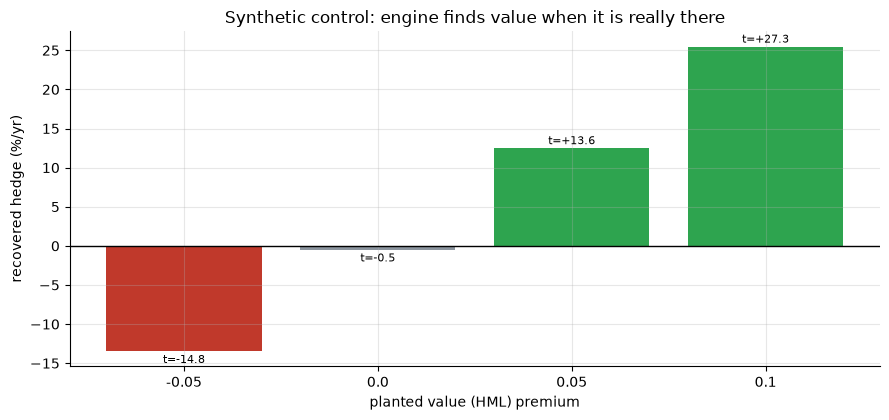

 premium  hedge_mean_%  tstat
   -0.05        -13.47 -14.83
    0.00         -0.49  -0.54
    0.05         12.49  13.64
    0.10         25.48  27.30


In [2]:
ctrl = st.synthetic_control(premiums=(-0.05, 0.0, 0.05, 0.10))
fig, ax = plt.subplots(figsize=(9.0, 4.3))
col = [GREEN if m > 0.5 else (RED if m < -0.5 else GREY) for m in ctrl['hedge_mean_%']]
ax.bar(ctrl['premium'].astype(str), ctrl['hedge_mean_%'], color=col)
ax.axhline(0, c='k', lw=1)
for i, (m, t) in enumerate(zip(ctrl['hedge_mean_%'], ctrl['tstat'])):
    ax.text(i, m + (0.5 if m >= 0 else -1.5), f't={t:+.1f}', ha='center', fontsize=8)
ax.set_xlabel('planted value (HML) premium'); ax.set_ylabel('recovered hedge (%/yr)')
ax.set_title('Synthetic control: engine finds value when it is really there')
plt.tight_layout(); plt.show()
print(ctrl.round(2).to_string(index=False))

The engine is faithful: positive premium in, positive hedge out (monotone); zero in, noise out. So whatever the real tape says reflects **the market**, not a broken detector.

**Now the honest test on the real yfinance panel.**

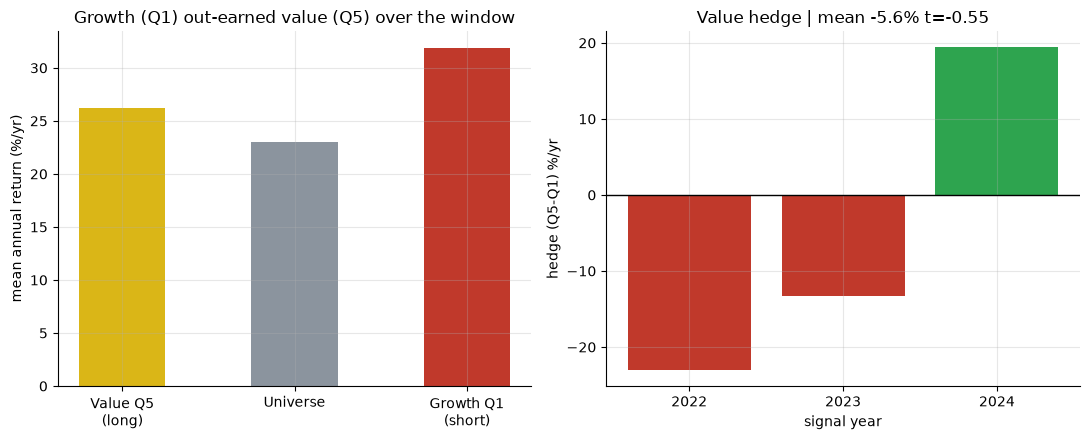

Value hedge: -5.62%/yr | HAC t = -0.554


In [3]:
if HAVE_REAL:
    val, gro, mkt = s_long['mean']*100, s_short['mean']*100, s_mkt['mean']*100
    hedge_m, hedge_t = s_hedge['mean']*100, s_hedge['tstat']
    annual = (sort['hedge']*100)
    annual.index = [int(y) for y in sort.index]
else:
    val, gro, mkt = R['value_leg'], R['growth_leg'], R['market']
    hedge_m, hedge_t = R['hedge_mean'], R['hedge_t']
    annual = pd.Series(R['annual'])

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['Value Q5\n(long)', 'Universe', 'Growth Q1\n(short)']
axes[0].bar(labels, [val, mkt, gro], color=[AMBER, GREY, RED], width=0.5)
axes[0].set_ylabel('mean annual return (%/yr)')
axes[0].set_title('Growth (Q1) out-earned value (Q5) over the window')
col_yr = [GREEN if v > 0 else RED for v in annual.values]
axes[1].bar(annual.index.astype(str), annual.values, color=col_yr)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_xlabel('signal year'); axes[1].set_ylabel('hedge (Q5-Q1) %/yr')
axes[1].set_title(f'Value hedge | mean {hedge_m:+.1f}% t={hedge_t:+.2f}')
plt.tight_layout(); plt.show()
print(f'Value hedge: {hedge_m:+.2f}%/yr | HAC t = {hedge_t:+.3f}')

The value hedge earns **-5.6%/yr** at HAC *t* = **-0.55** -- the *wrong sign* and far inside noise. Two of three years (2022 and 2023 signal) were sharply negative as mega-cap growth ran; only the 2024 signal year paid value. This is the textbook 'value is dead' regime.

## 5 -- The verdict

- **Signal -- NONE.** Hedge -5.62%/yr, HAC *t* = -0.55, placebo *p* = 0.58. Insignificant *and* the wrong sign -- literature cannot upgrade that.
- **Tradability -- MIRAGE.** Net -6.15%/yr on 3 annual observations. Nothing to trade.
- **Did value survive? -- BUSTED** on this modern survivor tape, even though the engine demonstrably works.

## 6 -- Could you actually trade it?

Even setting aside the negative sign, the obstacles are decisive:

1. **The data is too short.** Three annual cross-sections is not a backtest; it is an anecdote. yfinance simply does not expose enough fundamental history.
2. **Survivorship flatters the long leg.** Deep-value names that went bankrupt -- the natural value longs -- are absent, so even our negative result is an *upper bound* on what was achievable.
3. **Regime risk.** Value can underperform for a decade (2010-2020). Sizing a long-short value book through that requires conviction most investors lack.

On this evidence the practical verdict is **Mirage**.

## 7 -- Going further

- **A real fundamental database.** Compustat/CRSP back to the 1920s -- with delisted firms -- is where the value premium actually lives. The decisive limit here is the free data source, not the method.
- **Other value lenses.** [Study 124 -- Cash-Flow-Yield](../../124-cash-flow-yield/) (cash-based value), [Study 121 -- Magic-Formula](../../121-magic-formula/) (value + quality), [Study 243 -- Graham-NCAV](../../243-graham-ncav/) (deep liquidation value).
- **The same machinery on risk.** [Study 238 -- Betting-Against-Beta](../../238-betting-against-beta/) uses the identical annual sort + HAC inference on beta instead of B/M.

*Think value clears t > 2 net of costs on a survivorship-free, multi-decade panel? Fork this, swap in Compustat with delistings, and show it. That is the bar.*